# MMF 2021H Lecture 2 Homework

## Hashim Khan (1013626881)

### 2 Tasks

### 1. Simulation of KO and PEP Over Next Yr

####     1a. Compare yr end histograms


### 2. Weekly Return Historical Comparison 

####     2a. Weekly diff comparison




### Setup

In [17]:
## libraries

import pandas as pd 
import yfinance as yf
import numpy as np
import math
import matplotlib.pyplot as plt 
from scipy import stats

### Loading Historical Data from yfinance

* we pull last 10 years of adjusted closing price data using yfinance
    * This is done as stock splits and dividends create artifical jumps that do not represent real price action
    * i.e dividends not accounted for would understate the drift term as ex-dividend, prices drop roughly by the dividend amount


In [18]:

tickers = tickers
data = yf.download(tickers, period="10y", auto_adjust=True)["Close"].dropna()


[*********************100%***********************]  2 of 2 completed


In [19]:
#confirm we have 10 yr of data
print(f"{data[0:1]} \n {data[-1:]}")

Ticker             KO        PEP
Date                            
2016-10-03  30.826988  79.413788 
 Ticker             KO         PEP
Date                             
2026-10-02  85.650002  125.889999


## Task 1: Simulating KO and PEP Over the Next Year

### 1.1 Model Assumption

We assume each stock price follows a Geometric Brownian Motion (GBM) under the physical measure:

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where $\mu$ is the annualized drift, $\sigma$ the annualized volatility, and $W_t$ a standard Brownian motion. This implies:

- **Constant parameters:** $\mu$ and $\sigma$ do not change over the simulation horizon.
- **Continuous paths:** no jumps.
- **Lognormal prices:** equivalently, log returns are normally distributed and independent across time.
- **Correlated drivers:** KO and PEP are both consumer staples exposed to common shocks, so their Brownian motions are correlated: $dW_t^{KO} \, dW_t^{PEP} = \rho \, dt$.

### 1.2 Log Returns and Calibration

Applying Itô's lemma to $\ln S_t$:

$$
d(\ln S_t) = \left(\mu - \tfrac{1}{2}\sigma^2\right) dt + \sigma \, dW_t
$$

The $-\tfrac{1}{2}\sigma^2$ term is the Itô correction. It means daily log returns $r_t = \ln(S_t / S_{t-1})$ are i.i.d. with

$$
r_t \sim \mathcal{N}\!\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t, \; \sigma^2 \Delta t\right), \qquad \Delta t = \tfrac{1}{252}
$$

Inverting gives the estimators, using the sample mean $\bar{r}$ and sample standard deviation $s_r$ of daily log returns:

$$
\hat{\sigma} = \frac{s_r}{\sqrt{\Delta t}}, \qquad \hat{\mu} = \frac{\bar{r}}{\Delta t} + \tfrac{1}{2}\hat{\sigma}^2, \qquad \hat{\rho} = \text{corr}\left(r_t^{KO}, r_t^{PEP}\right)
$$

**Data choices:**
- Source: yfinance
- Prices: dividend-adjusted closes, so returns reflect total return. Unadjusted prices fall by roughly the dividend on each ex-date (Elton & Gruber, 1970), which would bias $\hat{\mu}$ downward.
- Parameter Estimation window: last 10 years.
- Starting price $S_0$: last available adjusted close 2026-10-02.


In [20]:
N = 252
M = 10000
dt = 1/N


logret = np.log(data[tickers]).diff().dropna()

sigma = logret.std() / np.sqrt(dt)
mu    = logret.mean() / dt + 0.5 * sigma**2
rho   = logret["KO"].corr(logret["PEP"])
S0    = data[tickers].iloc[-1]

params = pd.DataFrame({"S0": S0, "mu": mu, "sigma": sigma})
print(f"{params.round(4)} \n\nrho = {rho:.4f}")

mu_v, sig_v, S0_v = mu.values, sigma.values, S0.values


            S0      mu   sigma
Ticker                        
KO       85.65  0.1195  0.1848
PEP     125.89  0.0661  0.1995 

rho = 0.7098


### 1.3 Correlated Shocks

To impose correlation $\rho$, we draw independent $\varepsilon_1, \varepsilon_2 \sim \mathcal{N}(0,1)$ and apply the Cholesky decomposition of the 2×2 correlation matrix:

$$
Z^{KO} = \varepsilon_1, \qquad Z^{PEP} = \rho\,\varepsilon_1 + \sqrt{1-\rho^2}\,\varepsilon_2
$$

In [21]:
rng = np.random.default_rng(seed=42)
eps = rng.standard_normal((M, N, 2))
L = np.linalg.cholesky(np.array([[1, rho], [rho, 1]]))
Z = eps @ L.T

### 1.4 Discretizing the SDE

We simulate on a daily grid $t_k = k\Delta t$ for $k = 0, \dots, N$, with $N = 252$ trading days, using $M =$ [10,000] paths. Each step draws $Z_k \sim \mathcal{N}(0,1)$, so the Brownian increment is $\Delta W_k = \sqrt{\Delta t}\, Z_k$. We compare two schemes.

**Exact solution.** Because GBM has a closed-form solution (from 1.2), we can step it with no discretization error:

$$
S_{k+1} = S_k \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\, Z_k\right]
$$

**Euler–Maruyama with Milstein correction.** The plain Euler–Maruyama step discretizes the SDE directly in price space:

$$
S_{k+1} = S_k + \mu S_k \Delta t + \sigma S_k \sqrt{\Delta t}\, Z_k
$$

This has strong order 0.5. We improve it by adding the Milstein correction term $\tfrac{1}{2} b b' \left[(\Delta W_k)^2 - \Delta t\right]$.
For GBM, $b(S) = \sigma S$, so $b b' = \sigma^2 S$, and the corrected update is:

$$
S_{k+1} = S_k \left(1 + \mu \Delta t + \sigma \sqrt{\Delta t}\, Z_k + \tfrac{1}{2}\sigma^2 \Delta t \left(Z_k^2 - 1\right)\right)
$$

which raises the strong order to 1.

Both schemes use **the same draws $Z_k$**, so any difference between them is pure discretization error, not sampling noise. The exact scheme serves as the benchmark.

In [22]:
S_exact = np.empty((M, N + 1, 2))
S_em    = np.empty((M, N + 1, 2))
S_exact[:, 0, :] = S0_v
S_em[:, 0, :]    = S0_v

for k in range(N):
    z = Z[:, k, :]
    # Exact GBM step
    S_exact[:, k + 1, :] = S_exact[:, k, :] * np.exp(
        (mu_v - 0.5 * sig_v**2) * dt + sig_v * np.sqrt(dt) * z
    )
    # Euler–Maruyama with Milstein correction
    S_em[:, k + 1, :] = S_em[:, k, :] * (
        1 + mu_v * dt + sig_v * np.sqrt(dt) * z
        + 0.5 * sig_v**2 * dt * (z**2 - 1)
    )

ST_exact = S_exact[:, -1, :]
ST_em    = S_em[:, -1, :]

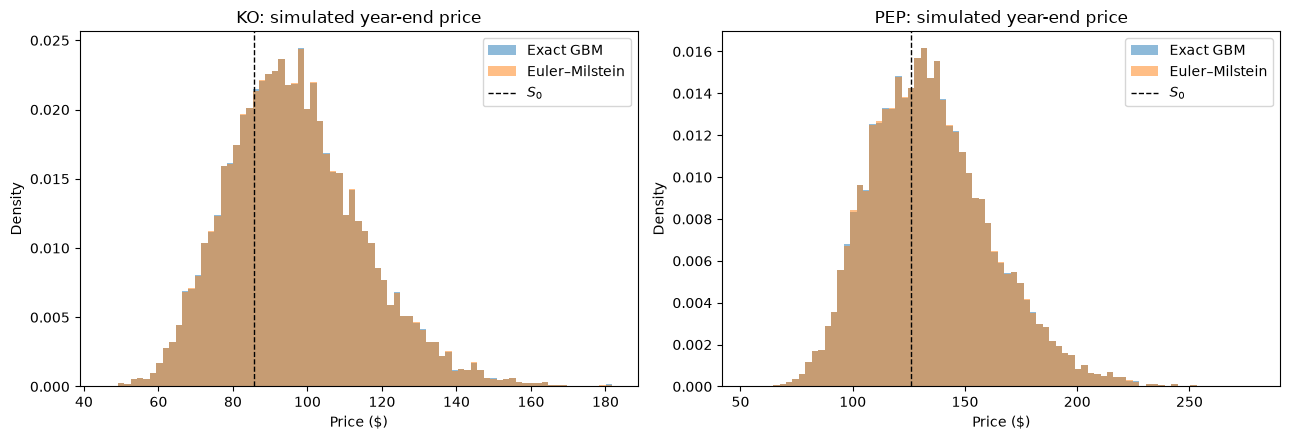

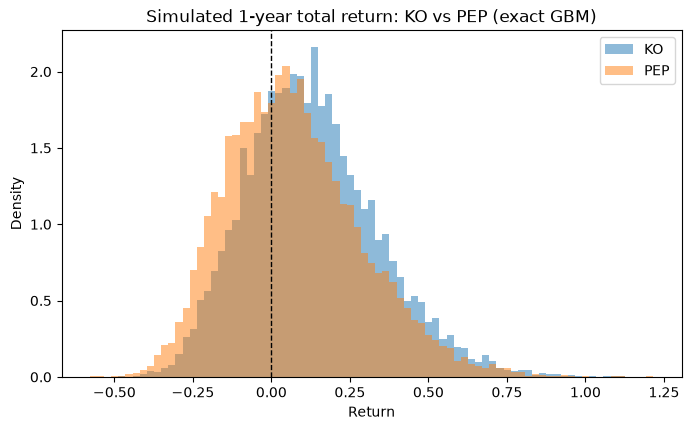

                      mean    std     5%  median     95%  theoretical mean
KO  Exact            96.75  18.07  69.69   95.26  129.19             96.53
    Euler–Milstein   96.75  18.07  69.70   95.26  129.17             96.53
PEP Exact           135.00  27.07  95.78  132.56  183.57            134.49
    Euler–Milstein  135.00  27.06  95.79  132.56  183.56            134.49
Max |exact − Euler–Milstein| at year end: [0.0601 0.0544]
Simulated corr of daily log returns: 0.7097


In [23]:
# ---------- Year-end histograms: exact vs Euler–Milstein, per stock ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, tk in enumerate(tickers):
    bins = np.linspace(min(ST_exact[:, i].min(), ST_em[:, i].min()),
                       max(ST_exact[:, i].max(), ST_em[:, i].max()), 80)
    axes[i].hist(ST_exact[:, i], bins=bins, alpha=0.5, density=True, label="Exact GBM")
    axes[i].hist(ST_em[:, i],    bins=bins, alpha=0.5, density=True, label="Euler–Milstein")
    axes[i].axvline(S0_v[i], color="k", ls="--", lw=1, label="$S_0$")
    axes[i].set(title=f"{tk}: simulated year-end price", xlabel="Price ($)", ylabel="Density")
    axes[i].legend()
plt.tight_layout(); plt.show()

# ---------- Year-end histograms: KO vs PEP (returns, so levels are comparable) ----------
R_exact = ST_exact / S0_v - 1
bins = np.linspace(R_exact.min(), R_exact.max(), 80)
plt.figure(figsize=(8, 4.5))
for i, tk in enumerate(tickers):
    plt.hist(R_exact[:, i], bins=bins, alpha=0.5, density=True, label=tk)
plt.axvline(0, color="k", ls="--", lw=1)
plt.title("Simulated 1-year total return: KO vs PEP (exact GBM)")
plt.xlabel("Return"); plt.ylabel("Density"); plt.legend(); plt.show()

# ---------- Summary statistics ----------
rows = {}
for i, tk in enumerate(tickers):
    for name, ST in [("Exact", ST_exact), ("Euler–Milstein", ST_em)]:
        x = ST[:, i]
        rows[(tk, name)] = {
            "mean": x.mean(), "std": x.std(),
            "5%": np.percentile(x, 5), "median": np.median(x), "95%": np.percentile(x, 95),
            "theoretical mean": S0_v[i] * np.exp(mu_v[i] * N * dt),
        }
summary = pd.DataFrame(rows).T
print(summary.round(2))

print("Max |exact − Euler–Milstein| at year end:", np.abs(ST_exact - ST_em).max(axis=0).round(4))
print("Simulated corr of daily log returns:",
      np.corrcoef(np.log(S_exact[:, 1:, 0] / S_exact[:, :-1, 0]).ravel(),
                  np.log(S_exact[:, 1:, 1] / S_exact[:, :-1, 1]).ravel())[0, 1].round(4))

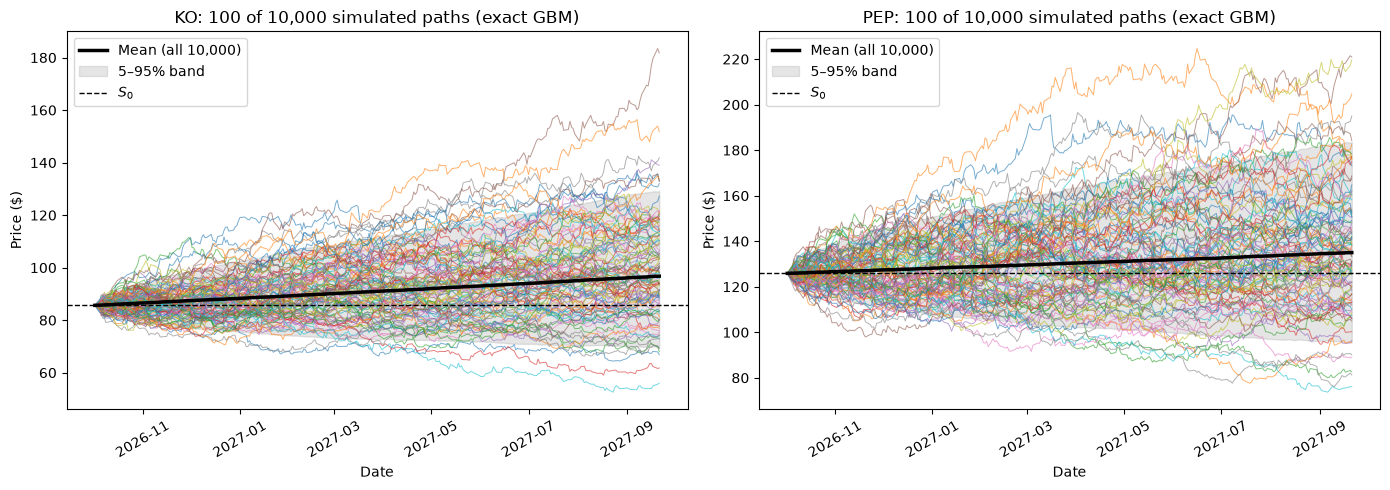

In [25]:
n_show = 100                                         # paths to draw
idx = np.random.default_rng(0).choice(M, n_show, replace=False)

dates = pd.bdate_range(start=data.index[-1], periods=N + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for i, tk in enumerate(tickers):
    paths = S_exact[:, :, i]
    ax = axes[i]

    ax.plot(dates, paths[idx].T, lw=0.7, alpha=0.6)  # subset, default color cycle

    ax.plot(dates, paths.mean(axis=0), color="k", lw=2.5, label=f"Mean (all {M:,})")
    ax.fill_between(dates,
                    np.percentile(paths, 5, axis=0),
                    np.percentile(paths, 95, axis=0),
                    color="grey", alpha=0.2, label="5–95% band")
    ax.axhline(S0_v[i], color="k", ls="--", lw=1, label="$S_0$")

    ax.set(title=f"{tk}: {n_show} of {M:,} simulated paths (exact GBM)",
           xlabel="Date", ylabel="Price ($)")
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


### 1.5 Reproducibility

We seed NumPy's random generator with `rng = np.random.default_rng(seed=42)`. All shocks are generated once, up front, as an array of shape `(M, N, 2)` and reused across both schemes, so results are reproducible and the schemes are directly comparable.

## Task 1: Weekly Returns and QQ-Plot of KO vs PEP

### 2.1 Weekly Returns

From the dividend-adjusted daily closes, we take the last close of each week (week ending Friday; holiday-shortened weeks use the last available close) and compute simple weekly returns over the past 10 years:

$$
R_w = \frac{P_w}{P_{w-1}} - 1
$$

Weekly sampling reduces microstructure noise and day-of-week effects relative to daily data.

### 2.2 Two-Sample QQ-Plot

A two-sample QQ-plot compares the empirical quantiles of KO against those of PEP. Because both series have the same number of observations, this amounts to plotting the sorted KO returns against the sorted PEP returns.

- **Same distribution:** points lie on the 45° line $y = x$.
- **Same shape, different location or scale:** points lie on a straight line with a different slope or intercept.
- **Different shape:** the plot curves, typically in the tails.

We show the plot on raw returns, which tests the full distribution, and on standardized returns $(R - \bar{R})/s_R$, which tests shape only, with location and scale removed.

### 2.3 Formal Tests

We complement the plot with nonparametric two-sample tests of $H_0$: KO and PEP weekly returns have the same distribution.

- **Kolmogorov–Smirnov:** based on the maximum gap between the two empirical CDFs. It is most sensitive near the centre of the distribution.
- **Anderson–Darling (k-sample):** places more weight on the tails, which matters for return data.

**Caveat:** both tests assume the two samples are independent. KO and PEP returns are contemporaneous and positively correlated, which tends to make the empirical CDFs move together and the tests conservative, that is, less likely to reject.

### 2.4 Results

| | Mean | Std | Skew | Excess Kurtosis |
|---|---|---|---|---|
| KO | [ ] | [ ] | [ ] | [ ] |
| PEP | [ ] | [ ] | [ ] | [ ] |

KS p-value (raw): [ ]   KS p-value (standardized): [ ]   AD p-value: [ ]

**Conclusion:** [Describe whether the points follow the 45° line, where they deviate (tails?), and whether the tests reject at the 5% level. If the raw test rejects but the standardized one does not, the distributions share a shape but differ in scale.]

521 weekly observations: 2016-10-14 to 2026-10-02
          mean     std    skew  excess kurtosis
Ticker                                         
KO      0.0023  0.0263 -1.1075          10.6515
PEP     0.0013  0.0263 -0.2403           7.5648


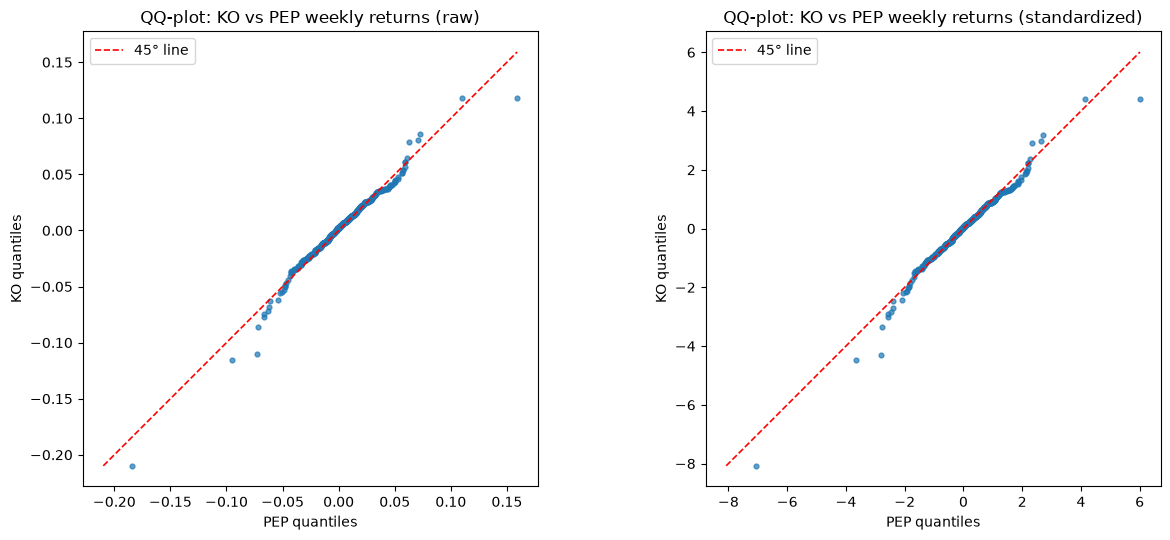

KS (raw):          D = 0.0710, p = 0.1445
KS (standardized): D = 0.0403, p = 0.7917
Anderson–Darling:  A = 0.1616, p ≈ 0.2500


C:\Users\hashi\AppData\Local\Temp\ipykernel_28804\2260878412.py:32: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  ad     = stats.anderson_ksamp([wk["KO"].values, wk["PEP"].values])
C:\Users\hashi\AppData\Local\Temp\ipykernel_28804\2260878412.py:32: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad     = stats.anderson_ksamp([wk["KO"].values, wk["PEP"].values])


In [26]:
from scipy import stats

# ---------- 3.1 Weekly returns ----------
weekly_px = data[tickers].resample("W-FRI").last()
wk = weekly_px.pct_change().dropna()
wk = wk.loc[wk.index[-1] - pd.DateOffset(years=10):]
print(f"{len(wk)} weekly observations: {wk.index[0].date()} to {wk.index[-1].date()}")

moments = pd.DataFrame({
    "mean": wk.mean(), "std": wk.std(),
    "skew": wk.skew(), "excess kurtosis": wk.kurt(),
})
print(moments.round(4))

# ---------- 3.2 Two-sample QQ-plots ----------
z = (wk - wk.mean()) / wk.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, df, label in [(axes[0], wk, "raw"), (axes[1], z, "standardized")]:
    ko_q, pep_q = np.sort(df["KO"].values), np.sort(df["PEP"].values)
    lo, hi = min(ko_q.min(), pep_q.min()), max(ko_q.max(), pep_q.max())
    ax.scatter(pep_q, ko_q, s=12, alpha=0.7)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="45° line")
    ax.set(title=f"QQ-plot: KO vs PEP weekly returns ({label})",
           xlabel="PEP quantiles", ylabel="KO quantiles")
    ax.set_aspect("equal"); ax.legend()
plt.tight_layout(); plt.show()

# ---------- 3.3 Formal tests ----------
ks_raw = stats.ks_2samp(wk["KO"], wk["PEP"])
ks_std = stats.ks_2samp(z["KO"], z["PEP"])
ad     = stats.anderson_ksamp([wk["KO"].values, wk["PEP"].values])

print(f"KS (raw):          D = {ks_raw.statistic:.4f}, p = {ks_raw.pvalue:.4f}")
print(f"KS (standardized): D = {ks_std.statistic:.4f}, p = {ks_std.pvalue:.4f}")
print(f"Anderson–Darling:  A = {ad.statistic:.4f}, p ≈ {ad.pvalue:.4f}")

## Task 4: Difference in Weekly Returns

### 4.1 Definition

We define the weekly return spread

$$
D_w = R_w^{KO} - R_w^{PEP}
$$

If KO and PEP returns were jointly normal, $D_w$ would be exactly normal, with

$$
\text{Var}(D) = \sigma_{KO}^2 + \sigma_{PEP}^2 - 2\rho\,\sigma_{KO}\sigma_{PEP}
$$

The positive correlation between the two stocks shrinks the variance of the spread, because common shocks to consumer staples largely cancel. What remains is mostly firm-specific news, which tends to arrive in jumps (earnings, guidance changes). That makes fat tails plausible even if each stock looks roughly normal on its own.

### 4.2 Normality Tests

We test $H_0$: $D_w$ is normally distributed, using:

- **QQ-plot vs the normal:** a visual check. Fat tails show up as an S-shape, with points below the line on the left and above it on the right.
- **Shapiro–Wilk:** a general-purpose test with good power in moderate samples.
- **Jarque–Bera:** tests whether skewness is 0 and excess kurtosis is 0.
- **D'Agostino K²:** combines tests on skewness and kurtosis.
- **Lilliefors:** the KS test against a normal whose mean and variance are estimated from the data. A plain KS test would be invalid here because the parameters are not known in advance.

With about 520 weekly observations, these tests have high power and will flag even modest departures from normality. The QQ-plot shows whether a rejection is driven by the tails or the centre.

### 4.3 Results

Mean: [ ]   Std: [ ]   Skew: [ ]   Excess kurtosis: [ ]

| Test | Statistic | p-value |
|---|---|---|
| Shapiro–Wilk | [ ] | [ ] |
| Jarque–Bera | [ ] | [ ] |
| D'Agostino K² | [ ] | [ ] |
| Lilliefors | [ ] | [ ] |

**Conclusion:** [State whether normality is rejected at 5%, and use the QQ-plot and excess kurtosis to say where the departure comes from. Connect this to Task 1: the GBM assumption of normal log returns understates tail risk.]

Var(D) = 0.000416  |  σ²_KO + σ²_PEP − 2Cov = 0.000416
mean = 0.00106, std = 0.02040, skew = -0.090, excess kurtosis = 3.309


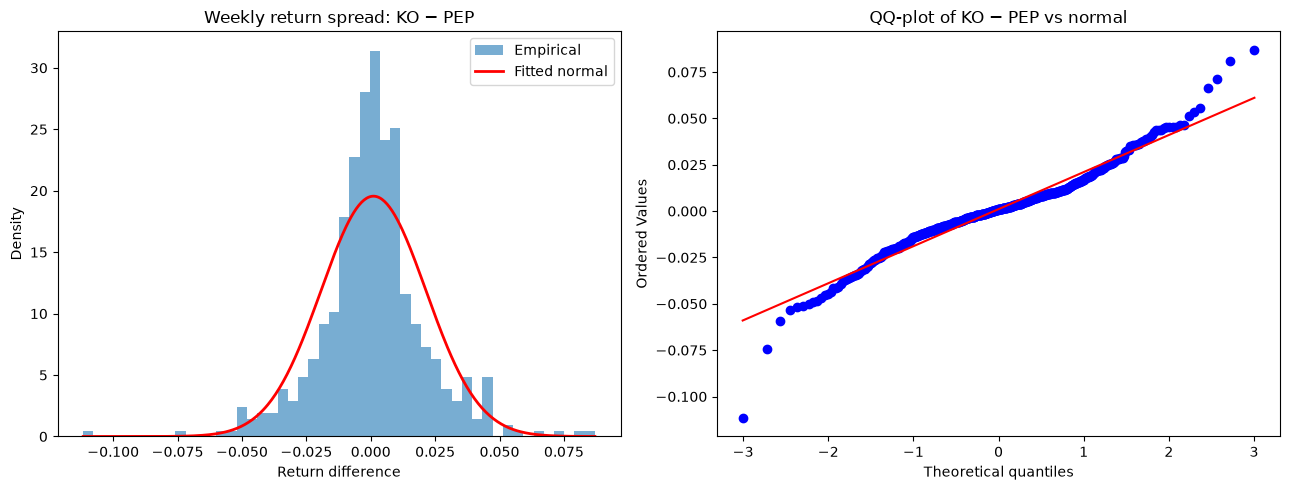

               statistic  p-value
Shapiro–Wilk      0.9567    0.000
Jarque–Bera     232.2688    0.000
D'Agostino K²    46.0553    0.000
Lilliefors        0.0864    0.001


In [28]:
from statsmodels.stats.diagnostic import lilliefors

# ---------- 4.1 Spread ----------
d = (wk["KO"] - wk["PEP"]).rename("KO − PEP")

var_check = wk["KO"].var() + wk["PEP"].var() - 2 * wk["KO"].cov(wk["PEP"])
print(f"Var(D) = {d.var():.6f}  |  σ²_KO + σ²_PEP − 2Cov = {var_check:.6f}")
print(f"mean = {d.mean():.5f}, std = {d.std():.5f}, "
      f"skew = {d.skew():.3f}, excess kurtosis = {d.kurt():.3f}")

# ---------- 4.2 Visual checks ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(d, bins=50, density=True, alpha=0.6, label="Empirical")
x = np.linspace(d.min(), d.max(), 400)
axes[0].plot(x, stats.norm.pdf(x, d.mean(), d.std()), "r", lw=2, label="Fitted normal")
axes[0].set(title="Weekly return spread: KO − PEP", xlabel="Return difference", ylabel="Density")
axes[0].legend()

stats.probplot(d, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot of KO − PEP vs normal")
plt.tight_layout(); plt.show()

# ---------- 4.3 Normality tests ----------
sw = stats.shapiro(d)
jb = stats.jarque_bera(d)
k2 = stats.normaltest(d)
lf_stat, lf_p = lilliefors(d, dist="norm")

tests = pd.DataFrame(
    {"statistic": [sw.statistic, jb.statistic, k2.statistic, lf_stat],
     "p-value":   [sw.pvalue,    jb.pvalue,    k2.pvalue,    lf_p]},
    index=["Shapiro–Wilk", "Jarque–Bera", "D'Agostino K²", "Lilliefors"],
)
print(tests.round(4))